<a href="https://colab.research.google.com/github/katherinexxxl/ADA-Assignment-Group-36/blob/main/Advanced_Data_Analytics_Group36_Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [211]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [212]:
# Load Dataset
data = 'https://raw.githubusercontent.com/katherinexxxl/ADA-Assignment-Group-36/refs/heads/main/early_2012_2013_loan_sample_with_outcome.csv'
df = pd.read_csv(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           50000 non-null  int64  
 1   member_id                    50000 non-null  int64  
 2   loan_amnt                    50000 non-null  int64  
 3   funded_amnt                  50000 non-null  int64  
 4   funded_amnt_inv              50000 non-null  float64
 5   term                         50000 non-null  float64
 6   int_rate                     50000 non-null  float64
 7   installment                  50000 non-null  float64
 8   grade                        50000 non-null  object 
 9   sub_grade                    50000 non-null  object 
 10  emp_title                    47168 non-null  object 
 11  emp_length                   48198 non-null  float64
 12  home_ownership               50000 non-null  object 
 13  annual_inc      

In [213]:
# Data Cleaning
# Check missing values
missing_counts = df.isna().sum()
print("\nMissing values per column:")
print(missing_counts)
# Note: 3 columns (tot_coll_amt, tot_cur_bal, total_credit_rv) share 14,618 missing values. Other blanks are acceptable given feature definitions.
# Check if all 3 columns' missing values occur in the same rows
co_missing = df[["tot_coll_amt", "tot_cur_bal", "total_credit_rv"]].isna().all(axis=1).sum()
print(f"\nRows where tot_coll_amt, tot_cur_bal AND total_credit_rv are all NA: {co_missing}")
# All missing values in the 3 features are contained in the same records.

# Data encoding & coversions
# Remove "%" from revol_util and convert to numeric
df["revol_util"] = np.array([
    float(str(x).replace("%", "")) if str(x).replace("%","").replace('.','',1).isdigit()
    else np.nan
    for x in df["revol_util"]])

# Convert loan_is_bad from boolean to 1/0 integer NumPy array
df["loan_is_bad"] = df["loan_is_bad"].astype(int)

# Create ordinal grade variable: A=1, B=2, ..., G=7
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
df["grade_ord"] = df["grade"].map({g: i + 1 for i, g in enumerate(grade_order)})

# Convert all remaining object/string columns to 'category' dtype
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")


Missing values per column:
id                                 0
member_id                          0
loan_amnt                          0
funded_amnt                        0
funded_amnt_inv                    0
term                               0
int_rate                           0
installment                        0
grade                              0
sub_grade                          0
emp_title                       2832
emp_length                      1802
home_ownership                     0
annual_inc                         0
verification_status                0
issue_d                            0
loan_status                        0
pymnt_plan                         0
desc                           18996
purpose                            0
title                              2
zip_code                           0
addr_state                         0
dti                                0
delinq_2yrs                        0
earliest_cr_line                   0
inq_last_6

In [214]:
# Selection & Further Data Prep
# Selecting features that are relevant for predicting loan default, only including information available at the loan decision point. Removing variables such as     "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "recoveries", "collection_recovery_fee", "last_pymnt_amnt"
# Only information available at the loan decision point is included.
select = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "revol_util",
    "total_acc",
    "grade_ord",
    "loan_is_bad"
]

df_select = df[select].copy()

# Checking data post selection
missing_counts_select = df_select.isna().sum()
print(missing_counts_select)

# Dropping NAs
df_select = df_select.dropna()

# Check data structure prep
print("\nData structure after data prep:")
df_select.info()

loan_amnt          0
int_rate           0
annual_inc         0
dti                0
delinq_2yrs        0
inq_last_6mths     0
revol_util        31
total_acc          0
grade_ord          0
loan_is_bad        0
dtype: int64

Data structure after data prep:
<class 'pandas.core.frame.DataFrame'>
Index: 49969 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       49969 non-null  int64  
 1   int_rate        49969 non-null  float64
 2   annual_inc      49969 non-null  float64
 3   dti             49969 non-null  float64
 4   delinq_2yrs     49969 non-null  int64  
 5   inq_last_6mths  49969 non-null  int64  
 6   revol_util      49969 non-null  float64
 7   total_acc       49969 non-null  int64  
 8   grade_ord       49969 non-null  int64  
 9   loan_is_bad     49969 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 4.2 MB


In [215]:
# Data Partitioning
X = df_select.drop("loan_is_bad", axis = 1) # independent features
y = df_select["loan_is_bad"] # target

# Split 1: Separate Test set (15%) from the rest (85%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=random_seed, stratify=y)

# Split 2: Separate Train (70% of total) and Validation (15% of total)
# 0.15 / 0.85 approx 0.176
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=random_seed, stratify=y_temp)

# Scale the data (fit only on training data to prevent data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [216]:
# Data Balancing
# Check for data imbalance in target
print(y.value_counts())
print("\nProportions:")
print(y.value_counts(normalize=True))
value_counts = y.value_counts()
imbalance_ratio = value_counts.min() / value_counts.max()
print(f"\nImbalance ratio in target: {imbalance_ratio:.4f}")

# Data balancing for training data using SMOTE
random_seed = 123
target_ratio = 0.67 # minority/majority
smote = SMOTE(sampling_strategy = target_ratio, random_state = random_seed)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

loan_is_bad
0    42161
1     7808
Name: count, dtype: int64

Proportions:
loan_is_bad
0    0.843743
1    0.156257
Name: proportion, dtype: float64

Imbalance ratio in target: 0.1852


In [217]:
# Convert to PyTorch Tensors
X_train_t = torch.FloatTensor(X_smote)
y_train_t = torch.LongTensor(y_smote.to_numpy())
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val.to_numpy())
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test.to_numpy())

In [218]:
# Create DataLoaders
# Checking number of entries in each set
print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

batch_size = 256
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)
# Not creating a dataloader for the validation set as the whole validation set will be used at once due to the class imbalance

Training samples: 34980, Validation samples: 7493, Test samples: 7496
(34980, 9) (34980,)
(7496, 9) (7496,)


In [219]:
# Define the model
class LoansModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.2):
        super(LoansModel, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output Layer
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [220]:
# Initialize the model, loss function, and optimizer
model = LoansModel(input_dim=X_train.shape[1], num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

# AdamW adds weight decay directly to the weight update rule for better regularization
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning Rate Decay: Reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [221]:
# Define training loop
epochs = 100
patience = 5
best_fnr = float('inf')
epochs_no_improve = 0
early_stop = False

train_losses, val_losses = [], []

for epoch in range(epochs):
    if early_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
      val_outputs = model(X_val_t.to(device))
      epoch_val_loss = criterion(val_outputs, y_val_t.to(device)).item()

      _, val_preds_t = torch.max(val_outputs, dim=1)
      val_preds = val_preds_t.cpu().numpy()
      val_labels = y_val_t.numpy()

    val_losses.append(epoch_val_loss)

    # Calculate FNR on validation set
    val_cm = confusion_matrix(val_labels, val_preds)
    tn, fp, fn, tp = val_cm.ravel()
    epoch_fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    scheduler.step(epoch_val_loss)

    # --- Early Stopping Logic ---
    if epoch_fnr < best_fnr:
        best_fnr = epoch_fnr
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

# every 5 steps we will print out the current loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val FNR: {epoch_fnr:.4f}")


Epoch 005/100 | Train Loss: 0.6285 | Val Loss: 0.5483 | Val FNR: 0.6063
Early stopping triggered at epoch 7



Metrics for model evaluation:
Accuracy: 0.7360
Precision: 0.2578
Recall (Sensitivity): 0.3672
F1-Score: 0.3029

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      6325
           1       0.26      0.37      0.30      1171

    accuracy                           0.74      7496
   macro avg       0.57      0.59      0.57      7496
weighted avg       0.78      0.74      0.75      7496


Important loan metrics:
Approval Rate: 0.7775
Default Rate (Approved):0.1271
False Negative Rate: 0.6328
Loss: 741.0000


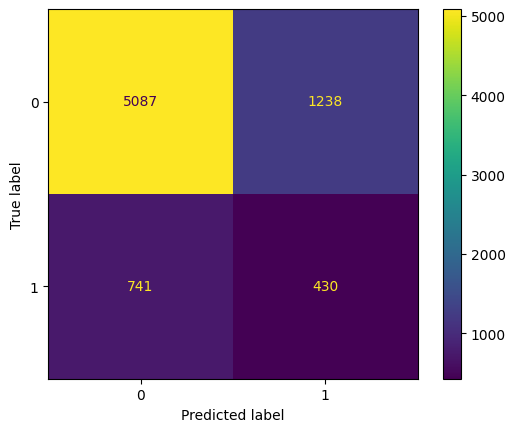

In [222]:
# Model Evaluation (Confusion Matrix & Important Metrics)
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Collect predictions and true labels for confusion matrix
        all_preds.extend(predicted.cpu().numpy()) # predictions
        all_labels.extend(labels.cpu().numpy()) # actual

# Calculate specific metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"\nMetrics for model evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["0", "1"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Custom credit / loan metrics
approval_rate = (fn + tn) / (tp + fp + tn + fn)
default_rate_approved = fn / (tn + fn) if (tn + fn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate:.4f}")
print(f"Default Rate (Approved):{default_rate_approved:.4f}")
print(f"False Negative Rate: {fnr:.4f}")
print(f"Loss: {fn:.4f}")

# Display confusion matrix
cm_display = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

Test Loss: 0.5641
Test Accuracy: 72.17%


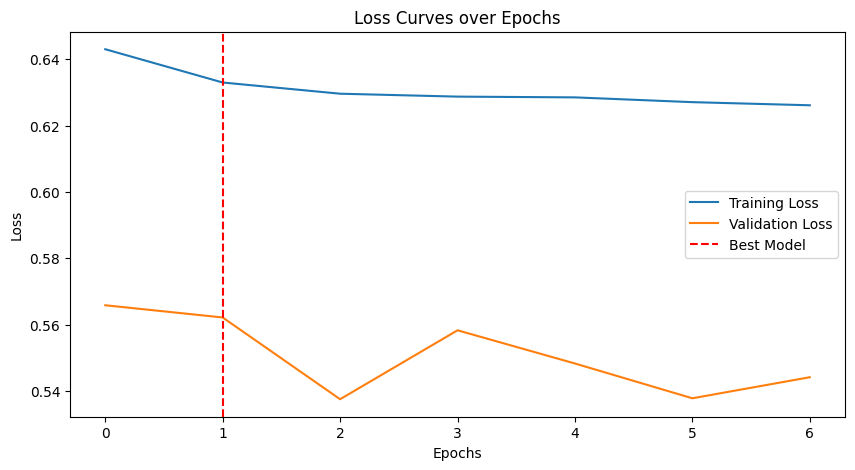

In [223]:
# Load the Best Model Weights Found During Training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct / total):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=len(train_losses) - epochs_no_improve - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [224]:
# Improving the model (adding a few more layers)
class LoansModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.2):
        super(LoansModel, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output Layer
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [234]:
# Re-initialize the model, loss function, and optimizer
model = LoansModel(input_dim=X_train.shape[1], num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

# Switching optimiser to SGD and lowering the learning rate from 0.001 to 0.0001
optimizer = optim.SGD(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Increasing the patience from 5 to 10
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [235]:
# Re-defining the training loop
epochs = 100
patience = 10 # increasing the patience from 5 to 10 here as well
best_fnr = float('inf')
epochs_no_improve = 0
early_stop = False

train_losses, val_losses = [], []

for epoch in range(epochs):
    if early_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
      val_outputs = model(X_val_t.to(device))
      epoch_val_loss = criterion(val_outputs, y_val_t.to(device)).item()

      _, val_preds_t = torch.max(val_outputs, dim=1)
      val_preds = val_preds_t.cpu().numpy()
      val_labels = y_val_t.numpy()

    val_losses.append(epoch_val_loss)

    # Calculate FNR on validation set
    val_cm = confusion_matrix(val_labels, val_preds)
    tn, fp, fn, tp = val_cm.ravel()
    epoch_fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    scheduler.step(epoch_val_loss)

    # --- Early Stopping Logic ---
    if epoch_fnr < best_fnr:
        best_fnr = epoch_fnr
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

# every 5 steps we will print out the current loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val FNR: {epoch_fnr:.4f}")

Epoch 005/100 | Train Loss: 0.7233 | Val Loss: 0.7088 | Val FNR: 0.4663
Epoch 010/100 | Train Loss: 0.7011 | Val Loss: 0.6663 | Val FNR: 0.5645
Early stopping triggered at epoch 11



Metrics for model evaluation:
Accuracy: 0.6243
Precision: 0.1801
Recall (Sensitivity): 0.3954
F1-Score: 0.2475

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.67      0.75      6325
           1       0.18      0.40      0.25      1171

    accuracy                           0.62      7496
   macro avg       0.52      0.53      0.50      7496
weighted avg       0.75      0.62      0.67      7496


Important loan metrics:
Approval Rate: 0.6570
Default Rate (Approved):0.1438
False Negative Rate: 0.6046
Loss: 708.0000


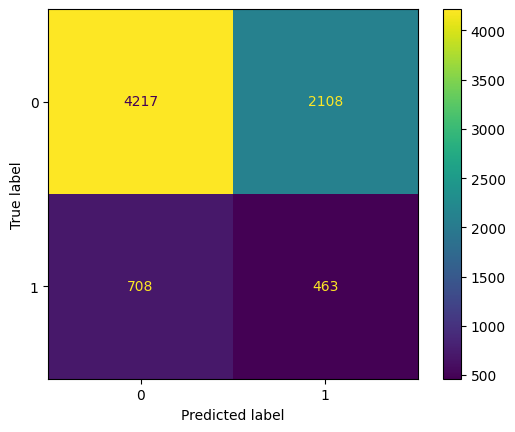

In [236]:
# Model Evaluation for improved model (Confusion Matrix & Important Metrics)
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Collect predictions and true labels for confusion matrix
        all_preds.extend(predicted.cpu().numpy()) # predictions
        all_labels.extend(labels.cpu().numpy()) # actual

# Calculate specific metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"\nMetrics for model evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["0", "1"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Custom credit / loan metrics
approval_rate = (fn + tn) / (tp + fp + tn + fn)
default_rate_approved = fn / (tn + fn) if (tn + fn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate:.4f}")
print(f"Default Rate (Approved):{default_rate_approved:.4f}")
print(f"False Negative Rate: {fnr:.4f}")
print(f"Loss: {fn:.4f}")

# Display confusion matrix
cm_display = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

Test Loss: 0.7741
Test Accuracy: 40.03%


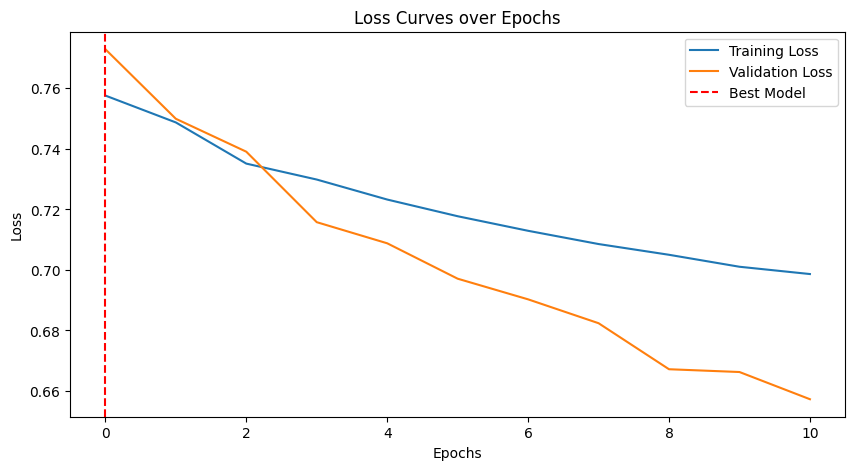

In [237]:
# Load the Best Model Weights Found During Training for Improved Model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct / total):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=len(train_losses) - epochs_no_improve - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()